In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd

df = pd.read_csv("CAR DETAILS FROM CAR DEKHO (1).csv")

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Shape: (4340, 8)

Columns:
['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']

First 5 rows:


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner



Data types:
name               str
year             int64
selling_price    int64
km_driven        int64
fuel               str
seller_type        str
transmission       str
owner              str
dtype: object

Missing values:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

Duplicate rows:
763


In [3]:
# Remove duplicate rows

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (3577, 8)


In [4]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


### Data Cleaning Observation

The dataset initially contained 4,340 records and 763 duplicate rows.
The duplicate records were removed to prevent repeated observations from
affecting the machine learning models.

After removing duplicates, the dataset contains 3,577 unique records.

In [5]:
# Check unique values in categorical columns

print("Fuel types:")
print(df['fuel'].unique())

print("\nSeller types:")
print(df['seller_type'].unique())

print("\nTransmission types:")
print(df['transmission'].unique())

print("\nOwner types:")
print(df['owner'].unique())

Fuel types:
<StringArray>
['Petrol', 'Diesel', 'CNG', 'LPG', 'Electric']
Length: 5, dtype: str

Seller types:
<StringArray>
['Individual', 'Dealer', 'Trustmark Dealer']
Length: 3, dtype: str

Transmission types:
<StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str

Owner types:
<StringArray>
[         'First Owner',         'Second Owner', 'Fourth & Above Owner',
          'Third Owner',       'Test Drive Car']
Length: 5, dtype: str


In [6]:
# Remove extra spaces and standardize categorical values

categorical_columns = [
    'fuel',
    'seller_type',
    'transmission',
    'owner'
]

for column in categorical_columns:
    df[column] = df[column].str.strip().str.title()

In [7]:
for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


fuel:
<StringArray>
['Petrol', 'Diesel', 'Cng', 'Lpg', 'Electric']
Length: 5, dtype: str

seller_type:
<StringArray>
['Individual', 'Dealer', 'Trustmark Dealer']
Length: 3, dtype: str

transmission:
<StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str

owner:
<StringArray>
[         'First Owner',         'Second Owner', 'Fourth & Above Owner',
          'Third Owner',       'Test Drive Car']
Length: 5, dtype: str


In [8]:
# Descriptive statistics for numerical columns

df.describe()

,year,selling_price,km_driven
count,3577.000000,3.577000e+03,3577.000000
mean,2012.962538,4.739125e+05,69250.545709
std,4.251759,5.093018e+05,47579.940016
min,1992.000000,2.000000e+04,1.000000
25%,2010.000000,2.000000e+05,36000.000000
50%,2013.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [9]:
print("Minimum year:", df['year'].min())
print("Maximum year:", df['year'].max())

Minimum year: 1992
Maximum year: 2020


In [10]:
# Calculate car age

current_year = 2026

df['car_age'] = current_year - df['year']

df[['year', 'car_age']].head()

,year,car_age
0,2007,19
1,2007,19
2,2012,14
3,2017,9
4,2014,12


In [11]:
print("Minimum car age:", df['car_age'].min())
print("Maximum car age:", df['car_age'].max())

Minimum car age: 6
Maximum car age: 34


In [13]:
# Extract brand from car name

df['brand'] = df['name'].str.split().str[0]

df[['name', 'brand']].head()

,name,brand
0,Maruti 800 AC,Maruti
1,Maruti Wagon R LXI Minor,Maruti
2,Hyundai Verna 1.6 SX,Hyundai
3,Datsun RediGO T Option,Datsun
4,Honda Amaze VX i-DTEC,Honda


In [14]:
print("Number of unique brands:", df['brand'].nunique())

Number of unique brands: 29


In [15]:
print(df['brand'].value_counts().head(15))

brand
Maruti        1072
Hyundai        637
Mahindra       328
Tata           308
Ford           220
Honda          216
Toyota         170
Chevrolet      151
Renault        110
Volkswagen      93
Nissan          52
Skoda           49
Fiat            32
Audi            31
Datsun          29
Name: count, dtype: int64


In [16]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age,brand
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,19,Maruti
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,19,Maruti
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,14,Hyundai
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,9,Datsun
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,12,Honda


In [17]:
print(df.shape)

(3577, 10)


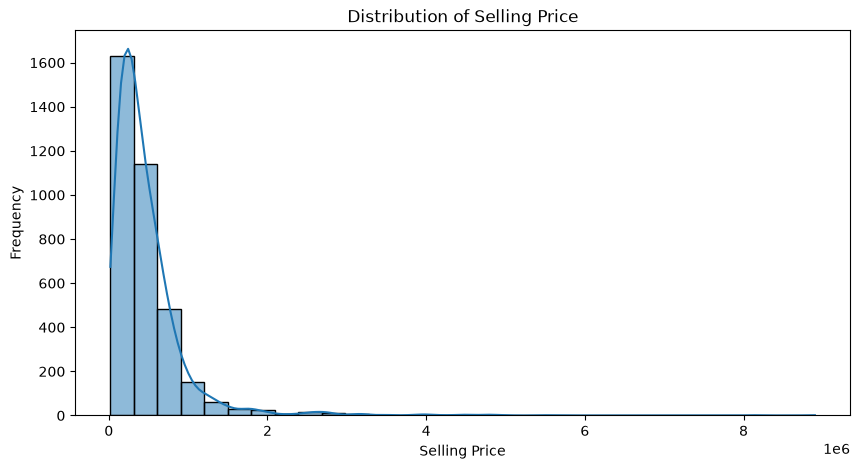

In [20]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='selling_price',
    bins=30,
    kde=True
)

plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')

plt.show()

### Observation

The selling price distribution is strongly right-skewed. Most used cars
have relatively lower selling prices, while a small number of cars have
substantially higher prices.

The presence of these high-priced vehicles creates a long right tail in
the distribution.

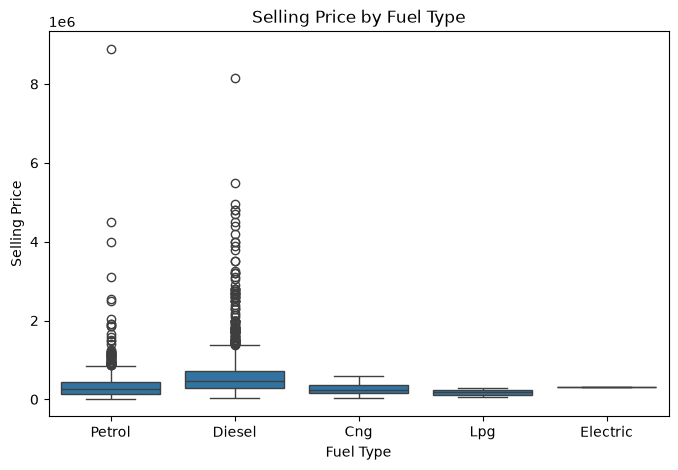

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='fuel',
    y='selling_price'
)

plt.title('Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price')

plt.show()

### Observation

The selling price varies across different fuel types. Diesel and Petrol
vehicles show wider price distributions and several high-priced outliers,
while CNG and LPG vehicles are concentrated within relatively lower price
ranges.

The Electric category contains very few observations, so conclusions about
electric vehicles should be interpreted cautiously.

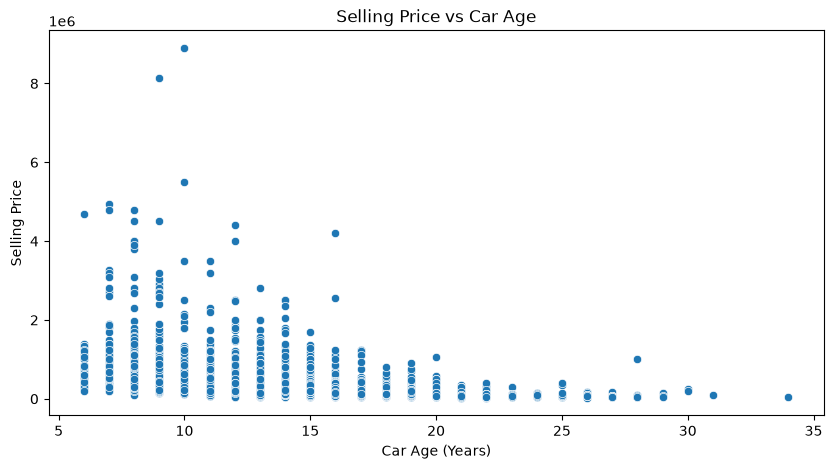

In [22]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df,
    x='car_age',
    y='selling_price'
)

plt.title('Selling Price vs Car Age')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price')

plt.show()

### Observation

The scatter plot shows a general negative relationship between car age and
selling price. Newer cars tend to have higher selling prices, while older
cars are generally sold at lower prices.

There is considerable variation in selling prices among newer vehicles,
indicating that factors other than age also influence the selling price.

In [23]:
# Select numerical columns for correlation analysis

numerical_columns = [
    'year',
    'selling_price',
    'km_driven',
    'car_age'
]

correlation_matrix = df[numerical_columns].corr()

correlation_matrix

,year,selling_price,km_driven,car_age
year,1.00000,0.424260,-0.417490,-1.00000
selling_price,0.42426,1.000000,-0.187359,-0.42426
km_driven,-0.41749,-0.187359,1.000000,0.41749
car_age,-1.00000,-0.424260,0.417490,1.00000


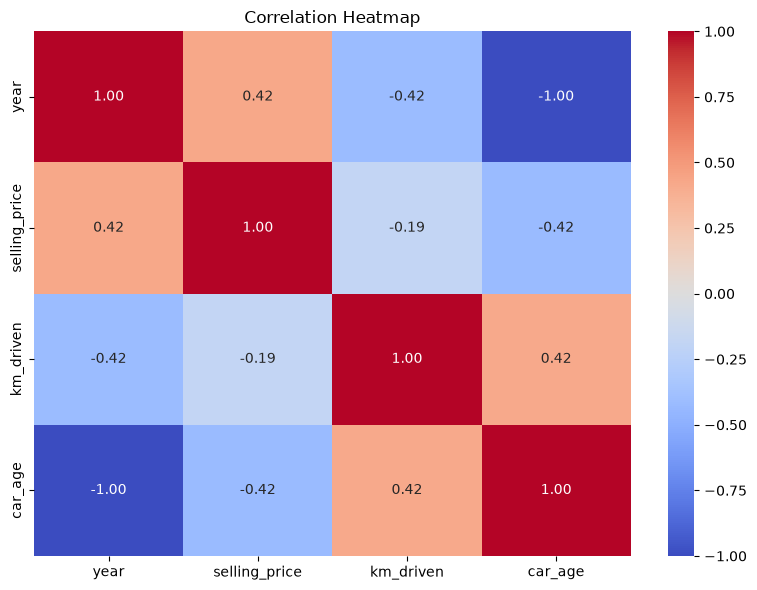

In [24]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

### Observation

The correlation heatmap shows that car age has a moderate negative
correlation with selling price (-0.42), indicating that older cars tend
to have lower selling prices.

Year has a moderate positive correlation with selling price (0.42),
which is consistent with newer cars generally having higher prices.

Kms driven has a weaker negative correlation with selling price (-0.19),
suggesting that cars with higher mileage tend to have somewhat lower
selling prices.

Year and car age have a perfect negative correlation (-1.00) because
car age was calculated directly from the year. Therefore, year will be
excluded from the machine learning features and car age will be used
instead.

In [26]:
# Define features and target

X = df[
    [
        'km_driven',
        'fuel',
        'seller_type',
        'transmission',
        'owner',
        'car_age',
        'brand'
    ]
]

y = df['selling_price']

In [33]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (2861, 7)
Testing data: (716, 7)


In [27]:
# Identify categorical columns

categorical_columns = [
    'fuel',
    'seller_type',
    'transmission',
    'owner',
    'brand'
]

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['fuel', 'seller_type', 'transmission', 'owner', 'brand']


In [28]:
numerical_columns = [
    'km_driven',
    'car_age'
]

In [29]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [30]:
# Create OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

In [31]:
# Apply One-Hot Encoding to categorical columns
# Keep numerical columns unchanged

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', encoder, categorical_columns)
    ],
    remainder='passthrough'
)

In [34]:
# Fit the encoder on training data and transform it

X_train_encoded = preprocessor.fit_transform(X_train)

# Transform the test data

X_test_encoded = preprocessor.transform(X_test)

In [35]:
print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)

Encoded training shape: (2861, 43)
Encoded testing shape: (716, 43)


In [36]:
# Get feature names after One-Hot Encoding

feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))
print(feature_names)

Number of features: 43
['categorical__fuel_Cng' 'categorical__fuel_Diesel'
 'categorical__fuel_Lpg' 'categorical__fuel_Petrol'
 'categorical__seller_type_Dealer' 'categorical__seller_type_Individual'
 'categorical__seller_type_Trustmark Dealer'
 'categorical__transmission_Automatic' 'categorical__transmission_Manual'
 'categorical__owner_First Owner'
 'categorical__owner_Fourth & Above Owner'
 'categorical__owner_Second Owner' 'categorical__owner_Test Drive Car'
 'categorical__owner_Third Owner' 'categorical__brand_Ambassador'
 'categorical__brand_Audi' 'categorical__brand_BMW'
 'categorical__brand_Chevrolet' 'categorical__brand_Daewoo'
 'categorical__brand_Datsun' 'categorical__brand_Fiat'
 'categorical__brand_Force' 'categorical__brand_Ford'
 'categorical__brand_Honda' 'categorical__brand_Hyundai'
 'categorical__brand_Jaguar' 'categorical__brand_Jeep'
 'categorical__brand_Land' 'categorical__brand_MG'
 'categorical__brand_Mahindra' 'categorical__brand_Maruti'
 'categorical__brand_Mer

In [38]:
# model 1

# Import Linear Regression

from sklearn.linear_model import LinearRegression

In [39]:
# Create Linear Regression model

linear_model = LinearRegression()

# Train the model

linear_model.fit(X_train_encoded, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](43,)","[-61134.87,135834.4 ,-27108.29,...,-34824.66, -0.89,-36019.41]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.401e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,43
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(28)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](43,)","[2585751.36, 206.59, 35.71,..., 0. , 0. , 0. ]"


In [40]:
# Make predictions on the test data

y_pred_linear = linear_model.predict(X_test_encoded)

print(y_pred_linear[:10])

[ 518768.10671646  467999.84318641  963877.13790793 2191280.4649457
  136067.41815245  377286.59641229  154411.5380097   615138.89698334
  807634.90061751  415302.06153848]


In [41]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [42]:
# Calculate Mean Absolute Error

mae_linear = mean_absolute_error(
    y_test,
    y_pred_linear
)

print("Linear Regression MAE:", mae_linear)

Linear Regression MAE: 185447.1897917411


In [43]:
# Calculate Root Mean Squared Error

rmse_linear = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_linear
    )
)

print("Linear Regression RMSE:", rmse_linear)

Linear Regression RMSE: 380316.63157682243


In [44]:
# Calculate R-squared score

r2_linear = r2_score(
    y_test,
    y_pred_linear
)

print("Linear Regression R²:", r2_linear)

Linear Regression R²: 0.5509911090106697


In [45]:
# Model 2

# Import Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

In [46]:
# Create Random Forest model

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [47]:
# Train Random Forest

rf_model.fit(X_train_encoded, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [48]:
# Make predictions on the test data

y_pred_rf = rf_model.predict(X_test_encoded)

print(y_pred_rf[:10])

[ 568614.04401154  467032.43416667 1455669.908      2552529.98
  241550.          346724.99        181333.33333333  667298.59666667
  874612.39714286  467260.        ]


In [49]:
# Evaluate MAE
# Calculate MAE

mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

# Calculate RMSE

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

# Calculate R²

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)
print("Random Forest R²:", r2_rf)

Random Forest MAE: 159531.37055443533
Random Forest RMSE: 367367.7192628899
Random Forest R²: 0.5810460504264773


In [50]:
# Compare model performance

results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest'
    ],
    'MAE': [
        mae_linear,
        mae_rf
    ],
    'RMSE': [
        rmse_linear,
        rmse_rf
    ],
    'R²': [
        r2_linear,
        r2_rf
    ]
})

results

,Model,MAE,RMSE,R²
0,Linear Regression,185447.189792,380316.631577,0.550991
1,Random Forest,159531.370554,367367.719263,0.581046


In [51]:
# Identify the best-performing model based on R²

best_model = results.loc[
    results['R²'].idxmax()
]

print("Best Model:", best_model['Model'])
print("MAE:", best_model['MAE'])
print("RMSE:", best_model['RMSE'])
print("R²:", best_model['R²'])

Best Model: Random Forest
MAE: 159531.37055443533
RMSE: 367367.7192628899
R²: 0.5810460504264773


In [52]:
rf_model.feature_importances_

array([1.02348570e-04, 6.84200417e-02, 2.47665000e-05, 4.46782837e-02,
       1.36685143e-02, 1.01878966e-02, 1.09777343e-03, 1.30746719e-01,
       1.13279075e-01, 9.38921931e-03, 3.55662608e-04, 5.15841540e-03,
       7.44313247e-04, 3.72880276e-03, 6.40376425e-06, 5.24681936e-02,
       1.38173147e-02, 3.27280703e-03, 7.55825560e-08, 7.68503180e-04,
       3.22897149e-04, 1.61355923e-05, 7.51012503e-03, 5.18224408e-03,
       6.55887477e-03, 1.01415520e-02, 3.00892063e-03, 4.02552186e-02,
       3.38034102e-03, 9.26616239e-03, 1.05423137e-02, 1.04113925e-02,
       2.21172240e-03, 6.69975198e-04, 2.44129404e-06, 1.62462882e-03,
       6.07982382e-03, 6.90257969e-03, 3.71223187e-02, 4.60653077e-03,
       7.89579465e-03, 1.30757167e-01, 2.23615711e-01])

In [53]:
# Get feature importance from Random Forest

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
})

# Sort features by importance

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
42,remainder__car_age,0.223616
41,remainder__km_driven,0.130757
7,categorical__transmission_Automatic,0.130747
8,categorical__transmission_Manual,0.113279
1,categorical__fuel_Diesel,0.068420
15,categorical__brand_Audi,0.052468
3,categorical__fuel_Petrol,0.044678
27,categorical__brand_Land,0.040255
38,categorical__brand_Toyota,0.037122
16,categorical__brand_BMW,0.013817


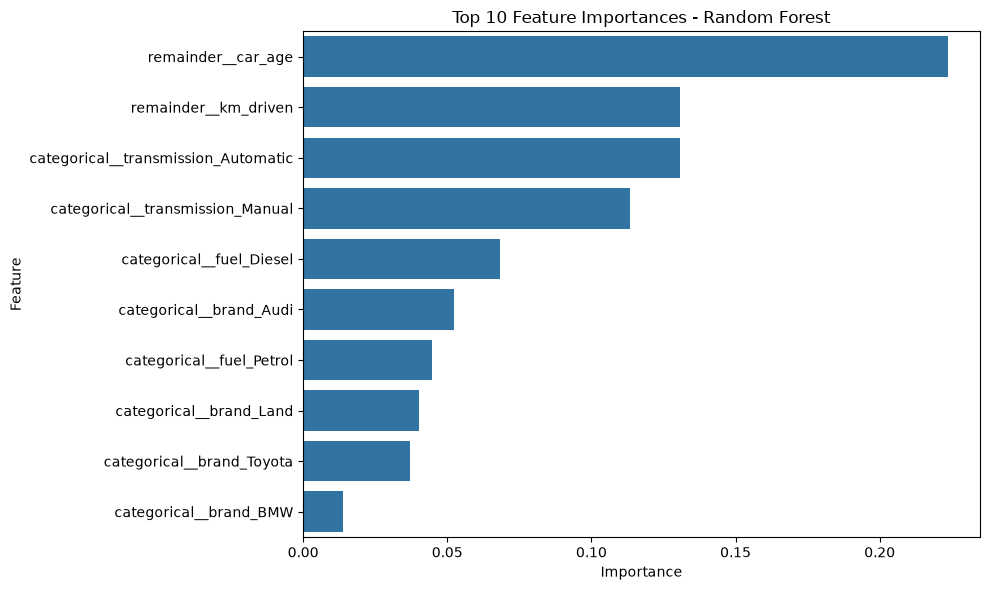

In [54]:
# Plot the top 10 important features

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

### Feature Importance Observation

The Random Forest model identified **car age** as the most important feature
for predicting selling price, with an importance score of approximately
0.224. This indicates that the age of the vehicle plays a major role in
determining its resale price.

**Kilometers driven** and **transmission type** were also among the most
important features. Fuel type and certain car brands, including Audi,
Land Rover, Toyota, and BMW, also contributed to the model's predictions.

Overall, the feature importance results suggest that vehicle age, usage,
transmission, fuel type, and brand are important factors associated with
used-car selling prices.

## Model Performance Summary

Two regression models were trained and evaluated:

- **Linear Regression**
  - MAE: 185,447.19
  - RMSE: 380,316.63
  - R²: 0.5510

- **Random Forest Regressor**
  - MAE: 159,531.37
  - RMSE: 367,367.72
  - R²: 0.5810

Random Forest performed better than Linear Regression because it achieved
lower MAE and RMSE and a higher R² score.

Therefore, **Random Forest Regressor was selected as the best-performing
model**.

# Conclusion

This project developed a machine learning model to predict the selling price
of used cars using vehicle characteristics such as car age, kilometers
driven, fuel type, seller type, transmission, ownership, and brand.

The dataset was cleaned by removing duplicate records and standardizing
categorical values. Feature engineering was performed by calculating car
age from the year of manufacture and extracting the brand from the car
name.

Exploratory data analysis showed that selling prices were strongly
right-skewed and that older cars generally had lower selling prices.
The analysis also showed differences in selling prices across fuel types.

Two regression models, Linear Regression and Random Forest Regressor, were
trained and evaluated using MAE, RMSE, and R².

Random Forest performed better, achieving an MAE of **159,531.37**, an RMSE
of **367,367.72**, and an R² score of **0.5810**. Therefore, Random Forest
was selected as the best-performing model.

Feature importance analysis showed that **car age** was the most important
feature, followed by kilometers driven and transmission-related features.

Overall, this project demonstrates the use of data cleaning, feature
engineering, exploratory data analysis, categorical encoding, regression
modeling, and model evaluation to predict used-car prices.